In [2]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException, TimeoutException, ElementNotInteractableException, ElementClickInterceptedException   
from datetime import datetime
import traceback
import os
import pandas as pd
import re
import numpy as np
from time import sleep
import urllib.parse

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [3]:
# Set up functions
def print_update(func):
    def wrapper(*args, **kwargs):
        print(f'Running {func.__name__}')
        return func(*args, **kwargs)
    return wrapper


def reject_cookies(driver, temp=0, retries=2):
    try:
        WebDriverWait(driver, retries).until(EC.element_to_be_clickable((By.ID, 'onetrust-reject-all-handler')))
        driver.find_element(By.ID, 'onetrust-reject-all-handler').click()
    except (NoSuchElementException, TimeoutException, ElementNotInteractableException, ElementClickInterceptedException):
        if temp >= retries:
            print(f'{retries} attempts failed to Reject cookies')
        else:
            reject_cookies(driver, temp + 1)


def skip_tutorial(driver, temp=0, retries=2):
    try:
        WebDriverWait(driver, retries).until(EC.element_to_be_clickable((By.CSS_SELECTOR, 'walla-button.TooltipWrapper__skip')))
        driver.find_element(By.CSS_SELECTOR, 'walla-button.TooltipWrapper__skip').click()
        driver.find_element(By.CSS_SELECTOR, 'walla-button.TooltipWrapper__skip').click()
        driver.find_element(By.CSS_SELECTOR, 'walla-button.TooltipWrapper__skip').click()
    except (NoSuchElementException, TimeoutException, ElementNotInteractableException, ElementClickInterceptedException):
        if temp >= retries:
            print(f'{temp} attempts failed to Skip the tutorial')
        else:
            skip_tutorial(driver, temp + 1)


def setup_driver():
    options = webdriver.ChromeOptions()
    options.set_capability("goog:loggingPrefs", {"performance": "INFO"})
    # prefs = {"profile.managed_default_content_settings.images": 2}
    # options.add_experimental_option("prefs", prefs)
    # options.add_argument("--headless")
    options.add_argument("--window-size=1920,1080")
    options.add_argument("--log-level=0")
    options.add_argument("--disable-extensions")
    

    driver = webdriver.Chrome(options=options)
    driver.maximize_window()

    driver.get('https://es.wallapop.com/app/search?filters_source=category_navigation&latitude=40.41956&longitude=-3.69196')

    reject_cookies(driver)
    skip_tutorial(driver)

    return driver


def load_more(driver, temp=0, retries=2):
    # Clicks button that initiates infinite scroll dynamic listings
    try:
        WebDriverWait(driver, retries).until(EC.element_to_be_clickable((By.ID, 'btn-load-more')))
        driver.find_element(By.ID, 'btn-load-more').click()
    except (NoSuchElementException, TimeoutException, ElementNotInteractableException, ElementClickInterceptedException):
        if temp >= retries:
            print(f'{temp} attempts failed to Click the load button')
        else:
            load_more(driver, temp + 1)


def wait_product(driver, temp=0, retries=3):
    try:
        WebDriverWait(driver, retries).until(EC.element_to_be_clickable((By.CSS_SELECTOR, 'a.ItemCardList__item')))
        return True
    except (NoSuchElementException, TimeoutException, ElementNotInteractableException, ElementClickInterceptedException):
        if temp >= retries:
            print(f'{temp} attempts failed to Find listings')
        else:
            wait_product(driver, temp + 1)

In [4]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time
import json

driver = setup_driver()
url = "https://es.wallapop.com/app/search?category_ids=24200&object_type_ids=9447&latitude=40.41956&longitude=-3.69196&filters_source=quick_filters&order_by=closest"
driver.get_log("performance")

[{'level': 'INFO',
  'message': '{"message":{"method":"Page.frameStartedLoading","params":{"frameId":"CD42A0DE81CBE14C36C2F587F722C601"}},"webview":"CD42A0DE81CBE14C36C2F587F722C601"}',
  'timestamp': 1723410291764},
 {'level': 'INFO',
  'message': '{"message":{"method":"Network.requestWillBeSent","params":{"documentURL":"https://es.wallapop.com/app/search?filters_source=category_navigation&latitude=40.41956&longitude=-3.69196","frameId":"CD42A0DE81CBE14C36C2F587F722C601","hasUserGesture":false,"initiator":{"type":"other"},"loaderId":"E94E8ADC58B036CFA13E7CE0B2B9E52E","redirectHasExtraInfo":false,"request":{"headers":{"Upgrade-Insecure-Requests":"1","User-Agent":"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/127.0.0.0 Safari/537.36","sec-ch-ua":"\\"Not)A;Brand\\";v=\\"99\\", \\"Google Chrome\\";v=\\"127\\", \\"Chromium\\";v=\\"127\\"","sec-ch-ua-mobile":"?0","sec-ch-ua-platform":"\\"macOS\\""},"initialPriority":"VeryHigh","isSameSite":tru

In [13]:
logs = driver.get_log("performance")

In [14]:
import json

df = pd.DataFrame()
for i, log in enumerate(logs):
    log_json = json.loads(log["message"])["message"]
    if log_json["method"] == 'Network.requestWillBeSent':
        try:
            response_url = log_json["params"]["documentURL"]
            if response_url.startswith("https://api.wallapop.com/api/v3/search?"):
                request_id = log_json["params"]["initiator"]["requestId"]
                try:
                    response_body = driver.execute_cdp_cmd("Network.getResponseBody", {"requestId": request_id})
                    response_body_json = json.loads(response_body['body'])
                    json_df = pd.DataFrame(response_body_json['data']['section']['payload']['items'])
                    df = pd.concat([df, json_df])
                except Exception as e:
                    pass
        except KeyError:
            print(f'\n\n{log_json}')
df.head(5)

,id,user_id,title,description,category_id,price,images,reserved,location,shipping,favorited,bump,web_slug,created_at,modified_at,taxonomy,is_favoriteable,is_refurbished
0,9jdkeyvk196k,8j3y87ddy169,Apple iPhone 13 256GB Verde - Revisado,"Marca: Apple\nModelo: iPhone 13\nCapacidad de almacenamiento: 256 GB\nColor: Verde\nAccesorios: cable de carga \n\n🔋 Salud de la batería: +85% \n✅ Revisado: funciona correctamente \n🚫 Precio no negociable \n🚚 Envío gratis \n🔒 Factura y garantia de 1 año \n\nEl iPhone 13 reacondicionado es una excelente opción para aquellos que buscan un dispositivo de alta calidad a un precio más asequible. Este modelo ha sido restaurado y verificado por expertos para asegurar su buen funcionamiento, por lo que puedes estar seguro de que obtendrás un producto de calidad.\nEl iPhone 13 cuenta con una pantalla Retina de 6.1 pulgadas, con una resolución de 2532 x 1170 píxeles, lo que le permite mostrar imágenes y vídeos con una calidad impresionante. Además, cuenta con una cámara dual de 12 megapíxeles, que te permitirá capturar fotos y vídeos de alta calidad, incluso en condiciones de poca luz.\nEl iPhone 13 también cuenta con un procesador A15 Bionic, que te permitirá ejecutar varias tareas de manera rápida y fluida, incluso jugar juegos exigentes. Además, cuenta con una batería de larga duración que te permitirá usar tu dispositivo durante horas sin tener que preocuparte por recargarlo.\nEn resumen, el iPhone 13 reacondicionado es una excelente opción para aquellos que buscan un dispositivo de alta calidad a un precio asequible. Con su pantalla Retina de alta calidad, su cámara dual de 12 megapíxeles y su potente procesador A15 Bionic, este dispositivo te ofrecerá un rendimiento excepcional en una amplia variedad de tareas. Además, al ser reacondicionado, podrás ahorrar dinero al adquirirlo, sin sacrificar la calidad del producto.",24200,"{'amount': 483.0, 'currency': 'EUR'}","[{'average_color': '13C1AC', 'urls': {'small': 'https://cdn.wallapop.com/images/10420/h3/ef/__/c10420p1033637512/i5041733232.jpg?pictureSize=W320', 'medium': 'https://cdn.wallapop.com/images/10420/h3/ef/__/c10420p1033637512/i5041733232.jpg?pictureSize=W640', 'big': 'https://cdn.wallapop.com/images/10420/h3/ef/__/c10420p1033637512/i5041733232.jpg?pictureSize=W800'}}]",{'flag': False},"{'latitude': 40.42075510602411, 'longitude': -3.6887609899012093, 'postal_code': '28014', 'city': 'Madrid', 'region': 'Comunidad de Madrid', 'region2': 'Madrid', 'country_code': 'ES'}","{'item_is_shippable': True, 'user_allows_shipping': True, 'cost_configuration_id': '04cf65ea-42f5-11ed-b878-0242ac120002'}",{'flag': False},{'type': 'country'},apple-iphone-13-256gb-verde-revisado-1033637512,1722340466985,1722943742164,"[{'id': 24200, 'name': 'Tecnología y electrónica', 'icon': 'robot'}, {'id': 24201, 'name': 'Telefonía: móviles y smartwatches', 'icon': None}, {'id': 9447, 'name': 'Smartphones', 'icon': None}]",{'flag': True},{'flag': True}
1,e6589ne8dg6o,8j3y87ddy169,Apple iPhone 13 128GB Verde - Revisado,"Marca: Apple\nModelo: iPhone 13\nCapacidad de almacenamiento: 128 GB\nColor: Verde\nAccesorios: cable de carga \n\n🔋 Salud de la batería: +85% \n✅ Revisado: funciona correctamente \n🚫 Precio no negociable \n🚚 Envío gratis \n🔒 Factura y garantia de 1 año \n\nEl iPhone 13 reacondicionado es una excelente opción para aquellos que buscan un dispositivo de alta calidad a un precio más asequible. Este modelo ha sido restaurado y verificado por expertos para asegurar su buen funcionamiento, por lo que puedes estar seguro de que obtendrás un producto de calidad.\nEl iPhone 13 cuenta con una pantalla Retina de 6.1 pulgadas, con una resolución de 2532 x 1170 píxeles, lo que le permite mostrar imágenes y vídeos con una calidad impresionante. Además, cuenta con una cámara dual de 12 megapíxeles, que te permitirá capturar fotos y vídeos de alta calidad, incluso en condiciones de poca luz.\nEl iPhone 13 también cuenta con un procesador A15 Bionic, que te permitirá ejecut

In [63]:
import requests

api_url = "https://api.wallapop.com/api/v3/search?category_id=12800&subcategory_ids=10164&latitude=40.41956&longitude=-3.69196&source=quick_filters&show_multiple_sections=false" # first page


data = requests.get(api_url)
print(data.json())


{'data': {'section': {'payload': {'order': 'closest', 'title': 'Find what you want', 'items': [{'id': 'ejk8d82dvpjx', 'user_id': '4z4vq145nmzy', 'title': 'INTERCOMUNICADOR CON CAMARA INCORPORADA FREEDCONN', 'description': 'INTERCOMUNICADOR FREEDCONN R3, CON CAMARA INCORPORADA PODRAS GRABAR HACIA DELANTE O HACIA ATRAS, CARGA RAPIDA, 6 O 7 HORAS DE GRABACION EN 2K, BLUETOOTH 5.0 CON EL CHIP MAS RAPIDO QUE HAY EN EL MERCADO, HASTA 6 PILOTOS EN CONVERSACION CON 1000 METROS DE DISTANCIA, REDUCCION DE RUIDO HASTA UN 95% MENOS, RADIO FM INCORPORADA, FUNCION WIFI, IMPERMEABLE CON CERTIFICACION IP67, ALTAVOCES HQ SONY, NUESTRO MEJOR INTERCOMUNICADOR SIN DUDA, 2 AÑOS DE GARANTIA OFICIAL', 'category_id': 12800, 'price': {'amount': 169.0, 'currency': 'EUR'}, 'images': [{'average_color': '13C1AC', 'urls': {'small': 'https://cdn.wallapop.com/images/10420/h5/ac/__/c10420p1036806271/i5061502513.jpg?pictureSize=W320', 'medium': 'https://cdn.wallapop.com/images/10420/h5/ac/__/c10420p1036806271/i50615025

In [8]:
directory = 'data/24200/10414'
dfs = []
for filename in os.listdir(directory):
    if filename.endswith(".csv"):
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath)
        dfs.append(df)
listings = pd.concat(dfs)
listings

,id,user_id,title,description,reserved,web_slug,item_is_shippable,user_allows_shipping,date_last_modified,date_first_created,date_last_scraped,country_code,num_images,refurbished,currency,price_cents,Unnamed: 0,range_name,url,last_checked
0,pzp28g12v5j3,7v6gg4vodl6e,Tcom T550HVN08.3,Tcom procedente de tv con pantalla rota \n,0.0,tcom-t550hvn08-3-958214002,1.0,1.0,24061508.0,23112208.0,24081122.0,ES,2.0,0.0,EUR,1300.0,NaN,NaN,NaN,NaN
1,mzn22q7wmgzn,xpzp2mmq2lj3,DPS-182BP PLACA TV FUENTE ALIMENTACIÓN PHILIPS,placa fuente alimentación TV Philips en perfecto estado verificada y comprobada. 629 920 454 Francisco.,0.0,dps-182bp-placa-tv-fuente-alimentacion-philips-1000488673,1.0,1.0,24061313.0,24041413.0,24081122.0,ES,1.0,0.0,EUR,1300.0,NaN,NaN,NaN,NaN
2,qjwd72ln8ezo,xpzp2mmq2lj3,3139 123 60192 PLACA MAIN TV PHILIPS O SIMILAR,"placa main televisor philips o similar que lleve esta placa con este código 3139 123 60192, proviniente de desmantelamiento de taller de televisión. 629 920 454 Francisco.",0.0,3139-123-60192-placa-main-tv-philips-o-similar-639340777,1.0,1.0,24061317.0,21051118.0,24081122.0,ES,3.0,0.0,EUR,1300.0,NaN,NaN,NaN,NaN
3,36ewpw0own6d,p8j3y7gy1693,Base TV Samsung 46 pulgadas,"Base para televisor, tornillos y mopa incluidos",0.0,pie-tv-samsung-46-pulgadas-446825139,1.0,1.0,24061512.0,19122214.0,24081122.0,ES,8.0,0.0,EUR,1300.0,NaN,NaN,NaN,NaN
4,pj9mxn5o9v6e,4z4vn1q4kmzy,TV de 18 pulgadas,Se vende televisiyón de 18 pulgadas con TDT integrado HDMI y etcétera,0.0,tv-de-18-pulgadas-1021606137,1.0,0.0,24062016.0,24062016.0,24081122.0,ES,2.0,0.0,EUR,1300.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15310,8z8k18egxlz3,nz0go52mmrjo,Placa WiFi lg 47ln575s,"Placa WiFi lgp4750-13pl2 extraido de television lg 47ln575s\n\nTodas las piezas del televisor han salido de una unidad con la pantalla rota, incluidos polvo y suciedad, pero nada que afecte su rendimiento. \nTesteada y verificada al 100%.\nDisponemos de muchas más placas de otros modelos, consulte sin compromiso.\n\n¡¡¡¡ NOTA ¡¡¡¡\n\nTodas nuestras placas están testeada s y no aceptamos devoluciones por si la montas en tu tele y tienes otro componente dañado y puede estropear nuestra placa",0.0,placa-wifi-lg-47ln575s-973585070,1.0,1.0,24080512.0,24011511.0,24081123.0,ES,3.0,0.0,EUR,1395.0,NaN,NaN,NaN,NaN
15311,nzx458g85mj2,nz0go52mmrjo,QUASAR - RICAMBIO MAZ645709 LGEKR#1-2 PER TV LG43L,"QUASAR - RICAMBIO MAZ645709 LGEKR#1-2 PER TV LG43L\n\nTodas las piezas del televisor han salido de una unidad con la pantalla rota, incluidos polvo y suciedad, pero nada que afecte su rendimiento. \nTesteada y verificada al 100%.\nDisponemos de muchas más placas de otros modelos, consulte sin compromiso.\n\n¡¡¡¡ NOTA ¡¡¡¡\n\nTodas nuestras placas están testeada y no aceptamos devoluciones por si la montas en tu tele y tienes otro componente dañado y puede estropear nuestra placa",0.0,quasar-ricambio-maz645709-lgekr-1-2-per-tv-lg43l-976605178,1.0,1.0,24072613.0,24012511.0,24081123.0,ES,3.0,0.0,EUR,1392.0,NaN,NaN,NaN,NaN
15312,wzy4n7r7kxz5,nz0go52mmrjo,botón encendido SAMSUNG UE40KU6100W,botón encendido SAMSUNG UE40KU6100W,0.0,boton-encendido-samsung-ue40ku6100w-972520592,1.0,1.0,24080512.0,24011117.0,24081123.0,ES,3.0,0.0,EUR,1350.0,NaN,NaN,NaN,NaN
15313,wzy4n7rlv5z5,nz0go52mmrjo,botón de encendido lg 47ln575s,"Luces LED con botón de encendido lg p4750-13pl2 extraído de television lg 47ln575s\n\nTodas las piezas del televisor han salido de una unidad con la pantalla rota, incluidos polvo y suciedad, pero nada que afecte su rendimiento. \nTesteada y verificada al 100%.\nDisponemos de muchas más placas de otros modelos, consulte sin compromiso.\n\n¡¡¡¡ NOTA ¡¡¡¡\n\nTodas nuestras placas están testeada y no aceptamos devoluciones por si la montas en tu tele y tienes otro componente dañado y puede estropear nuestra placa",0.0,boton-de-encendido-lg-47ln575s-972519268,1.0,1.0,24080512.0,24011117.0,24081123.0,ES,4.0,0.0,EUR,1350.0,NaN,NaN,NaN,NaN

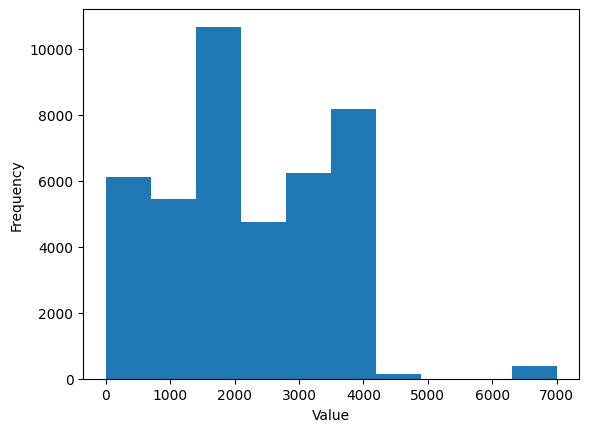

In [11]:
import matplotlib.pyplot as plt

listings['price_cents']

plt.hist(listings['price_cents'])
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()